# Converting rotations
Convert rotations from blender to SpinDOE and Martius

In [7]:
import numpy as np
import torch
import roma

In [8]:
rot_vecA = np.array([2.0, 0.0, 0.0])
rot_vecB = np.array([0.0, 2.0, 0.0])
rot_vecC = np.array([10.0, 2.0, -5.0])

# Transform exponential to Rotation matrix

In [9]:
def euler_angle_to_matrix(euler_angle: np.array) -> np.ndarray:
    """Convert euler angles to rotation matrix.
    using the Rodriguez rotation formula

    Args:
        euler_angle (np.ndarray): Euler angles in radians.

    Returns:
        np.ndarray: Rotation matrix.
    """
    theta = np.linalg.norm(euler_angle)
    euler_angle = euler_angle / theta
    K = np.array([[0, -euler_angle[2], euler_angle[1]],[euler_angle[2], 0, -euler_angle[0]],[ -euler_angle[1], euler_angle[0], 0]])
    matrix = np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * np.matmul(K, K)
    return matrix

In [10]:
rot_matA = euler_angle_to_matrix(rot_vecA)
print(f"Rotation Matrix A:\n{rot_matA}\n")

Rotation Matrix A:
[[ 1.          0.          0.        ]
 [ 0.         -0.41614684 -0.90929743]
 [ 0.          0.90929743 -0.41614684]]



NameError: name 'edges' is not defined

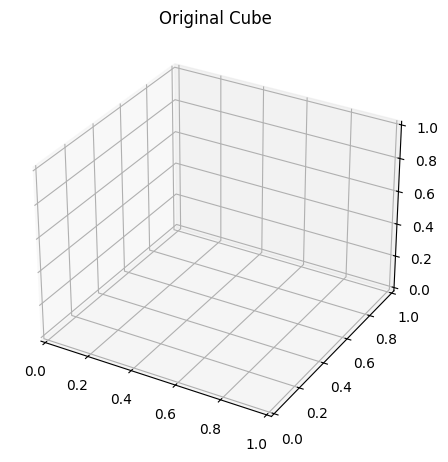

In [15]:
from mpl_toolkits.mplot3d import Axes3D

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(18, 6))

# 1. Original Cube
ax1 = fig.add_subplot(131, projection='3d')
ax1.set_title('Original Cube')
for edge in edges:
    ax1.plot(*cube_vertices[edge].T, color='b')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_zlim(zlim)

# 2. Cube rotated by rot_matA
rotated_by_matA = cube_vertices @ rot_matA.T
ax2 = fig.add_subplot(132, projection='3d')
ax2.set_title('Rotated by rot_matA')
for edge in edges:
    ax2.plot(*rotated_by_matA[edge].T, color='g')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_xlim(xlim)
ax2.set_ylim(ylim)
ax2.set_zlim(zlim)

# 3. Cube rotated around axis rot_vecA
def axis_angle_to_matrix(axis: np.ndarray, angle: float) -> np.ndarray:
    axis = axis / np.linalg.norm(axis)
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    I = np.eye(3)
    return I + np.sin(angle) * K + (1 - np.cos(angle)) * (K @ K)

angleA = np.linalg.norm(rot_vecA)
axisA = rot_vecA / angleA
rot_mat_axisA = axis_angle_to_matrix(axisA, angleA)
rotated_by_axisA = cube_vertices @ rot_mat_axisA.T

ax3 = fig.add_subplot(133, projection='3d')
ax3.set_title('Rotated around axis rot_vecA')
for edge in edges:
    ax3.plot(*rotated_by_axisA[edge].T, color='r')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_xlim(xlim)
ax3.set_ylim(ylim)
ax3.set_zlim(zlim)

plt.tight_layout()
plt.show()

# Rotation matrix to euler angles

In [17]:
def matrix_to_axis_angle(R: np.ndarray):
    """
    Convert a rotation matrix to axis-angle representation.

    Args:
        R (np.ndarray): 3x3 rotation matrix.

    Returns:
        axis (np.ndarray): Rotation axis (unit vector).
        angle (float): Rotation angle in radians.
    """
    angle = np.arccos((np.trace(R) - 1) / 2)
    if np.isclose(angle, 0):
        axis = np.array([1, 0, 0])
    else:
        axis = np.array([
            R[2, 1] - R[1, 2],
            R[0, 2] - R[2, 0],
            R[1, 0] - R[0, 1]
        ]) / (2 * np.sin(angle))
    return axis, angle

def matrix_to_euler(R: np.ndarray):
    """
    Convert a rotation matrix to Euler angles (roll, pitch, yaw).

    Args:
        R (np.ndarray): 3x3 rotation matrix.

    Returns:
        euler_angles (np.ndarray): Euler angles in radians.
    """
    axis, angle = matrix_to_axis_angle(R)
    return axis * angle

# Example usage:
axis, angle = matrix_to_axis_angle(rot_matA)
print("Axis:", axis)
print("Angle:", angle)
print("Euler", matrix_to_euler(rot_matA))
print("rot_vecA:", rot_vecA)

Axis: [1. 0. 0.]
Angle: 2.0
Euler [2. 0. 0.]
rot_vecA: [2. 0. 0.]


# Use SVD to recover R from matrix

In [18]:
def procrustes_to_rotmat(A: np.ndarray) -> np.ndarray:
    """
    Use SVD to recover the closest rotation matrix from a given matrix A.

    Args:
        A (np.ndarray): Input matrix.
    """
    # perform SVD+
    u, s, v = np.linalg.svd(A)
    det = np.linalg.det(u @ v.T)
    dia = np.diag([1, 1, det])
    R = u @ dia @ v.T
    # roma needs torch tensors [B, 3, 3]
    # print(R.shape)
    R_torch = torch.tensor(R, dtype=torch.float32).unsqueeze(0)
    R_roma = roma.special_procrustes(R_torch).squeeze(0).numpy()
    return R_roma

In [68]:
rotmat_random = rot_matA + 0.1 * np.random.randn(3,3)
rotmat_random2 = rot_matA + 0.01 * np.random.randn(3,3)

In [69]:
mat = procrustes_to_rotmat(rotmat_random)
mat2 = procrustes_to_rotmat(rotmat_random2)
print(f"Recovered Rotation Matrix:\n{mat}\n")
print("Recovered Euler:", matrix_to_euler(mat))
print("Recovered Euler 2:", matrix_to_euler(mat2))
print("Original Euler:", rot_vecA)

Recovered Rotation Matrix:
[[ 0.9620526  -0.16085155 -0.22041231]
 [-0.25793612 -0.27258036 -0.9269136 ]
 [ 0.08901542  0.948592   -0.30372605]]

Recovered Euler: [ 1.8554353  -0.30611643 -0.09604563]
Recovered Euler 2: [ 1.9123003   0.31510317 -0.83713126]
Original Euler: [2. 0. 0.]


# Calculate loss


In [72]:
def procrustes_to_rotmat_torch(A) -> torch.Tensor:
    """
    Use torch SVD to recover the closest rotation matrix from A.

    Accepts:
        A (np.ndarray or torch.Tensor): Input matrix (3x3) or batch (B,3,3).

    Returns:
        torch.Tensor: Rotation matrix (3x3) or batch (B,3,3), dtype float32.
    """
    # convert to torch tensor if needed
    if isinstance(A, np.ndarray):
        A_t = torch.tensor(A, dtype=torch.float32)
    elif torch.is_tensor(A):
        A_t = A.to(dtype=torch.float32)
    else:
        A_t = torch.tensor(A, dtype=torch.float32)

    # ensure batch dimension
    squeezed = False
    if A_t.dim() == 2:
        A_t = A_t.unsqueeze(0)
        squeezed = True

    # SVD (torch)
    u, s, v = torch.linalg.svd(A_t)
    # v returned such that A = u @ diag(s) @ v.transpose(-2,-1)
    det = torch.linalg.det(u @ v.transpose(-2, -1))

    # build correction diagonal matrix with last element = det
    I = torch.eye(3, dtype=A_t.dtype, device=A_t.device).unsqueeze(0).repeat(A_t.shape[0], 1, 1)
    dia = I.clone()
    dia[:, 2, 2] = det

    R = u @ dia @ v.transpose(-2, -1)

    # refine with roma if available (expects [B,3,3])
    try:
        R = roma.special_procrustes(R)
    except Exception:
        # fall back to SVD result if roma fails
        pass

    if squeezed:
        R = R.squeeze(0)

    return R

In [73]:
def rotation_loss(M_pred, R_gt, lam=1e-3):
    R_hat = procrustes_to_rotmat_torch(M_pred)
    loss_mat = torch.linalg.matrix_norm(R_hat - R_gt, ord='fro')**2
    proj = torch.linalg.matrix_norm(R_hat - M_pred, ord='fro')**2
    return loss_mat + lam * proj

In [75]:
print("Loss 1:", rotation_loss(torch.tensor(rotmat_random, dtype=torch.float32), torch.tensor(rot_matA, dtype=torch.float32)).item())
print("Loss 2:", rotation_loss(torch.tensor(rotmat_random2, dtype=torch.float32), torch.tensor(rot_matA, dtype=torch.float32)).item())

Loss 1: 0.18569248914718628
Loss 2: 1.0895788669586182


# Test as criterion

In [78]:
class RotationLoss(torch.nn.Module):
    def __init__(self, lam=1e-3):
        super(RotationLoss, self).__init__()
        self.lam = lam

    def forward(self, M_pred, R_gt):
        u, s, v = torch.linalg.svd(M_pred)
        det = torch.linalg.det(u @ v.transpose(-2, -1))
        I = torch.eye(3, dtype=M_pred.dtype, device=M_pred.device).unsqueeze(0).repeat(M_pred.shape[0], 1, 1)
        dia = I.clone()
        dia[:, 2, 2] = det
        R = u @ dia @ v.transpose(-2, -1)
        R = roma.special_procrustes(R)

        R_hat = R
        loss_mat = torch.linalg.matrix_norm(R_hat - R_gt, ord='fro')**2
        proj = torch.linalg.matrix_norm(R_hat - M_pred, ord='fro')**2
        return loss_mat.mean() + self.lam * proj.mean()

In [79]:
R_gt = torch.tensor([
    [[ 0.9951, -0.0383,  0.0912],
     [ 0.0414,  0.9990, -0.0185],
     [-0.0904,  0.0221,  0.9956]],

    [[ 0.9883, -0.0411, -0.1469],
     [ 0.0488,  0.9981,  0.0380],
     [ 0.1449, -0.0450,  0.9884]],

    [[ 0.9742, -0.2256,  0.0097],
     [ 0.2257,  0.9740, -0.0203],
     [-0.0048,  0.0213,  0.9998]],

    [[ 0.9603,  0.2777,  0.0262],
     [-0.2776,  0.9606, -0.0148],
     [-0.0290,  0.0070,  0.9996]],

    [[ 0.9994,  0.0053, -0.0333],
     [-0.0051,  0.9999,  0.0057],
     [ 0.0334, -0.0055,  0.9994]],

    [[ 0.9816, -0.1827,  0.0534],
     [ 0.1832,  0.9831, -0.0068],
     [-0.0517,  0.0164,  0.9985]],

    [[ 0.9532,  0.3021,  0.0043],
     [-0.3021,  0.9533, -0.0007],
     [-0.0040, -0.0005,  1.0000]],

    [[ 0.9972,  0.0752, -0.0068],
     [-0.0753,  0.9970,  0.0229],
     [ 0.0051, -0.0233,  0.9997]],
], dtype=torch.float32)
criterion = RotationLoss(lam=1e-3)
M_noisy = (R_gt + 0.05*torch.randn(8,3,3)).requires_grad_()
loss = criterion(M_noisy, R_gt)
loss.backward()
print("[Direkt-Test] Loss:", float(loss))
print("[Direkt-Test] Grad-Norm(M):", float(M_noisy.grad.norm()))


[Direkt-Test] Loss: 2.796879291534424
[Direkt-Test] Grad-Norm(M): 17.967830657958984


In [92]:
a = torch.ones((8, 3, 3))
b = torch.ones((8, 1))
b[2] = 0
b[7] = 0
print(b.shape)
#b = b.unsqueeze(-1)
print(b.shape)

print((a * b[:, None]).shape)
print(a * b[:, None])

torch.Size([8, 1])
torch.Size([8, 1])
torch.Size([8, 3, 3])
tensor([[[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]])
